Name: Olaofe Folayinka Oluwatoyosi

Student ID: 991843165

Title: Assignment 3 Linear Regression for Diabetes Progression Prediction

_______________________________________________________________________________

Dataset: Use sklearn.datasets.load_diabetes() (442 diabetes patients; 10 numeric features: age, sex, bmi, bp, s1–s6 for blood serum measures like T-chol, LDL, HDL, TC/HDL, log-triglycerides,
glucose; target is a quantitative measure of disease progression one year after baseline)

Prediction Question: Can patient baseline features (like BMI and blood pressure) predict diabetes disease progression one year later? This helps clinicians identify high-risk patients
early for intervention.

• Load and explore the data: show head, and summary statistics.

• Create scatter plots: y vs bmi and y vs age (two plots)

In [2]:
from sklearn.datasets import load_diabetes
import pandas as pd

diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names) 

y = diabetes.target

print(f"First 10 records from the dataset \n: {df.head(10)}")
print("\n\n")
print(f"Summary statistics of the dataset \n: {df.describe()}")


First 10 records from the dataset 
:         age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
5 -0.092695 -0.044642 -0.040696 -0.019442 -0.068991 -0.079288  0.041277   
6 -0.045472  0.050680 -0.047163 -0.015999 -0.040096 -0.024800  0.000779   
7  0.063504  0.050680 -0.001895  0.066629  0.090620  0.108914  0.022869   
8  0.041708  0.050680  0.061696 -0.040099 -0.013953  0.006202 -0.028674   
9 -0.070900 -0.044642  0.039062 -0.033213 -0.012577 -0.034508 -0.024993   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3

_______________________________________________________________________________

Y vs BMI Scatter Plot

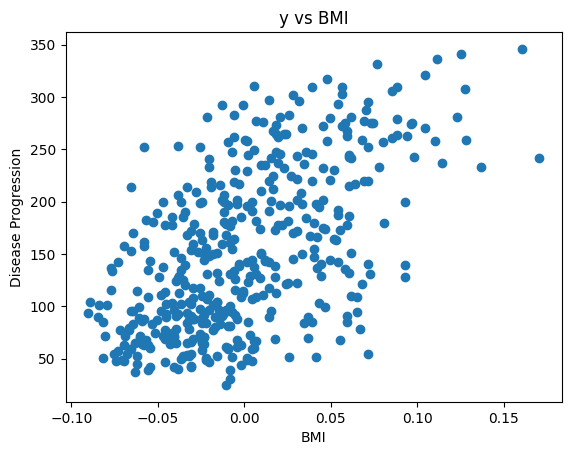

In [3]:
import matplotlib.pyplot as plt

bmi_df = df['bmi']

# Y (Target) bs BMI
plt.scatter(bmi_df,y)
plt.xlabel("BMI")
plt.ylabel("Disease Progression") # target y is disease propagation 
plt.title("y vs BMI")
plt.show()

_______________________________________________________________________________

Y vs Age Scatter Plot

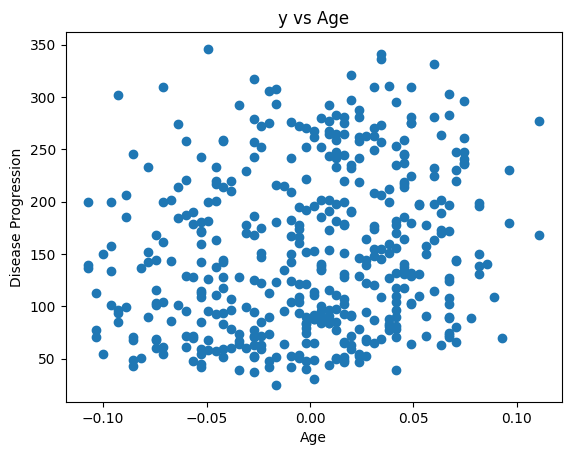

In [4]:
import matplotlib.pyplot as plt

age_df = df['age']

# Y (Target) vs Age
plt.scatter(age_df,y)
plt.xlabel("Age")
plt.ylabel("Disease Progression") # target y is disease propagation 
plt.title("y vs Age")
plt.show()

_______________________________________________________________________________

_______________________________________________________________________________

Part 2 - Model building tasks in Python

Use random_state=42 everywhere for reproducibility.

• Split into train/test sets using train_test_split with a fixed random_state.

• Fit a LinearRegression model from scikit-learn and generate predictions on both train
and test sets.

• print the intercept and coefficients, then map each coefficient back to its feature name.

• Compute metrics R².

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# SPliiting data into test & train
X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=0.2, random_state=42
)

# train the model
regression = LinearRegression()
model = regression.fit(X_train, y_train)

# run the predictions
y_pred_fromTrain = model.predict(X_train)
y_pred_fromTest = model.predict(X_test)

# Intercept
print("Intercept:", model.intercept_)

# Coefficients
print("\nCoefficients:")

for i in range(len(df.columns)):
    print(df.columns[i], ":", model.coef_[i])

# R^2 metrics
r2_train = r2_score(y_train, y_pred_fromTrain)
r2_test = r2_score(y_test, y_pred_fromTest)

print("\nR^2 Train:", r2_train)
print("R^2 Test:", r2_test)

Intercept: 151.34560453985995

Coefficients:
age : 37.904021350074835
sex : -241.96436231273955
bmi : 542.4287585162899
bp : 347.703843913856
s1 : -931.4888458835164
s2 : 518.0622769833383
s3 : 163.41998299131137
s4 : 275.3179015786478
s5 : 736.1988589046846
s6 : 48.67065743196522

R^2 Train: 0.5279193863361498
R^2 Test: 0.4526027629719198


_______________________________________________________________________________

_______________________________________________________________________________

Part 3 – Analytical Insights

• Plot residuals vs predicted values plot; ask if there is a pattern or if points are randomly
scattered.

• Interpretation of coefficients and metrics. For two selected features, interpret the sign
and approximate magnitude of the coefficient in plain language.

• Explain what the intercept means and whether it is meaningful in context.

• Interpret R²: what fraction of variability in the target is explained by the model and is
that “good enough” for this application.

• Compare simple vs multiple linear regression (one key predictor vs all predictors) and
discuss changes in R.

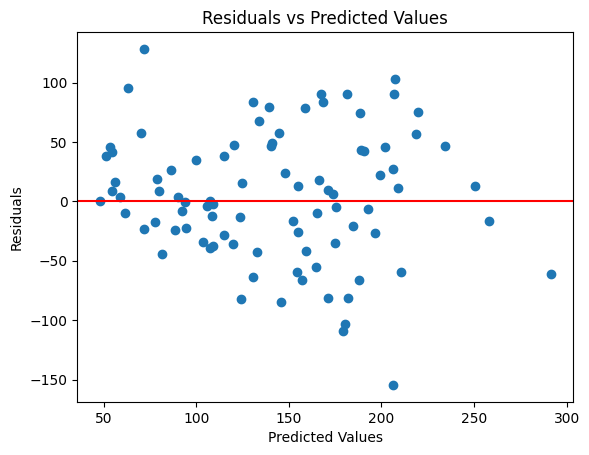

In [11]:
# Residuals
residuals = y_test - y_pred_fromTest


# Residual plot
plt.scatter(y_pred_fromTest, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.axhline(y=0,color='red')   # a reference line
plt.show()

Analysis of Residuals vs Predicted Values

The residuals appear to be mostly scattered around the zero line; with no clear pattern. This suggests the linear regression method/model used is reasnoably accurate. Although, we have some larger residuals that suggest prediction errors.

Interpretation of Two coefficients

The coefficient for BMI (542.4287585162899) is positive; this means that higher BMI is rleated with higher predicted diabetes progression.

The coefficient for blood pressure (347.703843913856) is also positive; meaning that higher BP tends to increase the predicted diabetes progression

Intercept

The intercept shows the predicted disease progression when all the features are equal to 0.

Simple vs Multiple Linear Regression

Simple regression using only one predictor (e.g. BMI) explains less variation in the target variable than multiple regression using all predictors. The multiple regression model usually has a higher R² because it has more information to work with.